In [1]:
import numpy as np

In [2]:
# variance

def variance (x):
    avg = x.mean()
    deviations = x - avg
    deivations_sq = deviations ** 2
    variance = deivations_sq.mean()
    return variance


rng = np.random.default_rng(seed = 33)
x = rng.integers(1,10, size = 6)
var = variance(x)

In [3]:

import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np
import statistics as stat


#mean, median, mode
df = sns.load_dataset('tips')

avg = np.mean(df['total_bill'])
med = np.median(df['total_bill'])
mod = stat.mode(df['total_bill'])

print(f"Mean = {avg}")
print(f"Median = {med}")
print(f"Mode = {mod}")

Mean = 19.78594262295082
Median = 17.795
Mode = 13.42


<Axes: xlabel='total_bill', ylabel='Count'>

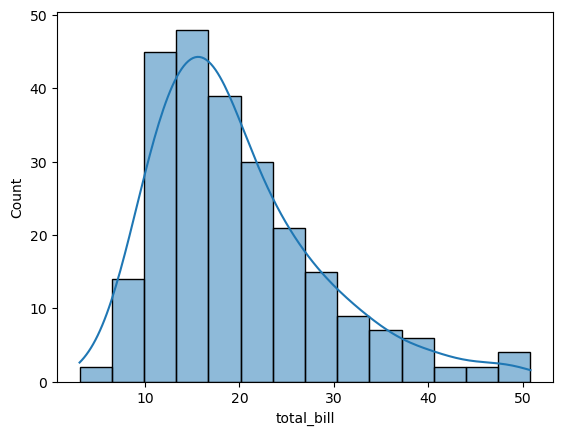

In [4]:
sns.histplot(df['total_bill'], kde = True)

<Axes: xlabel='sepal_width', ylabel='Count'>

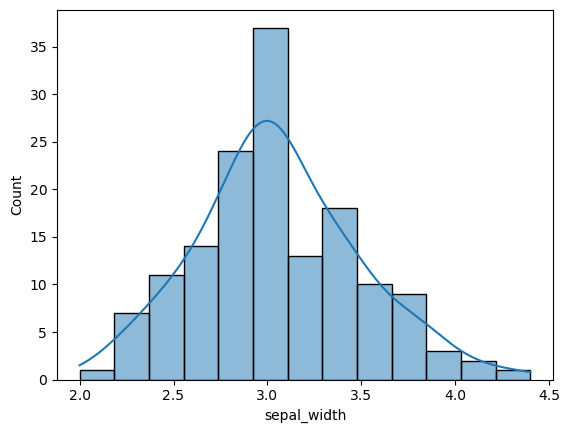

In [5]:
df1 = sns.load_dataset('iris')
sns.histplot(df1['sepal_width'], kde = True)

In [6]:
np.percentile(df1['sepal_width'], [25, 90, 45, 75])

array([2.8 , 3.61, 3.  , 3.3 ])

In [7]:
#Outliers
dt = [11, 10, 12, 14, 12, 15, 14, 13, 15, 102, 12, 14, 17, 19, 107, 
      10, 13, 12, 14, 12, 108, 12, 11, 14, 13, 15, 12, 10, 14, 13, 15, 10]


#Z_score
def detect_outliers(x):
    thresh = 3
    mean = np.mean(x)
    std = np.std(x)
    outliers = []

    for i in  x:
        z_score = (i - mean) / std
        if np.abs(z_score) >= thresh:
            outliers.append(i)

    return outliers

detect_outliers(dt)

[107, 108]

In [8]:
# # IQR
# 1. sort the data
# 2. find q3 and q1
# 3. lower_fence = q1 - 1.5(IQR)
#    higher_fence = q3 + 1.5(IQR)
#         IQR = q3 - q1


In [9]:
#outliers using IQR

def IQR(x):
    x = sorted(x)
    q1, q3 = np.percentile(x , [25, 75])
    lower_fence = q1 - (1.5 * (q3 - q1))
    higher_fence = q3 + (1.5 * (q3 - q1))

    return lower_fence, higher_fence



In [10]:
 (4/52) * ( 4/51)

0.006033182503770739

In [11]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [1]:
# Task Description

# You are given two machine learning models (Model A and Model B) trained on the same dataset. Their accuracy scores from 10-fold cross-validation are provided.
# 	1.	Descriptive Statistics
# 	•	Compute the mean, variance, standard deviation, skewness, and kurtosis of the accuracies for both models.
# 	•	Visualize the accuracies using box plots and histograms.
# 	2.	Inferential Statistics
# 	•	Construct a 95% confidence interval for the mean accuracy of each model.
# 	3.	Hypothesis Testing
# 	•	Formulate the hypotheses:
# 	•	H_0: There is no significant difference between the accuracies of Model A and Model B.
# 	•	H_1: There is a significant difference.
# 	•	Perform a paired t-test to test the hypothesis.
# 	•	Report the p-value and decision (reject or fail to reject H_0).
# 	4.	Interpretation
# 	•	Briefly interpret whether Model B is statistically significantly better than Model A.


# Dataset (Cross-validation accuracies)
# 	•	Model A: [0.82, 0.80, 0.83, 0.85, 0.81, 0.79, 0.84, 0.82, 0.83, 0.81]
# 	•	Model B: [0.84, 0.85, 0.86, 0.87, 0.83, 0.82, 0.88, 0.86, 0.87, 0.84]

C:\Users\USER\AppData\Local\Temp\ipykernel_24516\3583017976.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([A, B], labels = ["Model_A", "Model_B"])


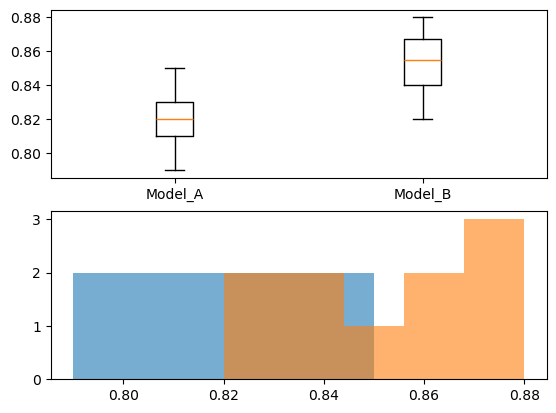

In [3]:
A = [0.82, 0.80, 0.83, 0.85, 0.81, 0.79, 0.84, 0.82, 0.83, 0.81]
B = [0.84, 0.85, 0.86, 0.87, 0.83, 0.82, 0.88, 0.86, 0.87, 0.84]

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 	1.	Descriptive Statistics

mean_A = np.mean(A)
var_A = np.var(A)
std_A = np.std(A)
skew_A = stats.skew(A)
kurt_A = stats.kurtosis(A)

mean_B = np.mean(B)
var_B = np.var(B)
std_B = np.std(B)
skew_B = stats.skew(B)
kurt_B = stats.kurtosis(B)


plt.subplot(2,1,1)
plt.boxplot([A, B], labels = ["Model_A", "Model_B"])

plt.subplot(2,1,2)
plt.hist(A, alpha = 0.6, bins=5, label="Model_A") 
plt.hist(B, alpha = 0.6, bins=5, label="Model_B") 

plt.show()


=== Descriptive Statistics ===
Model A: {'Mean': np.float64(0.82), 'Variance': np.float64(0.00033333333333333224), 'Std Dev': np.float64(0.01825741858350551), 'Skewness': np.float64(9.57285425464845e-15), 'Kurtosis': np.float64(-0.7999999999999958)}
Model B: {'Mean': np.float64(0.852), 'Variance': np.float64(0.000373333333333334), 'Std Dev': np.float64(0.019321835661585934), 'Skewness': np.float64(-0.19873415003635034), 'Kurtosis': np.float64(-1.0892857142857144)}

=== 95% Confidence Intervals ===
Model A: (np.float64(0.8069394295307695), np.float64(0.8330605704692304))
Model B: (np.float64(0.8381779914231127), np.float64(0.8658220085768873))

=== Paired t-test ===
t-statistic = -3.8066, p-value = 0.001298
Decision: Reject H0 (significant difference)


C:\Users\USER\AppData\Local\Temp\ipykernel_23896\3277965845.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([model_a, model_b], labels=["Model A", "Model B"])


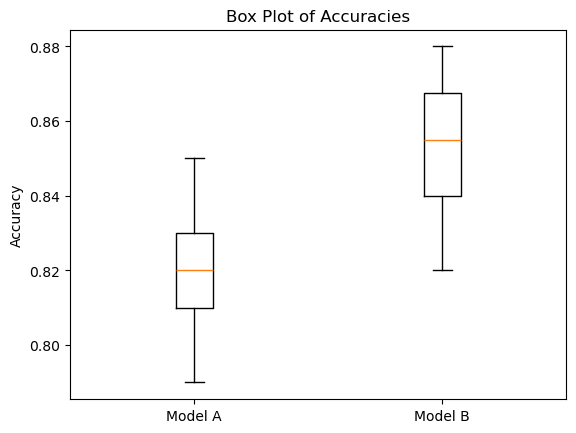

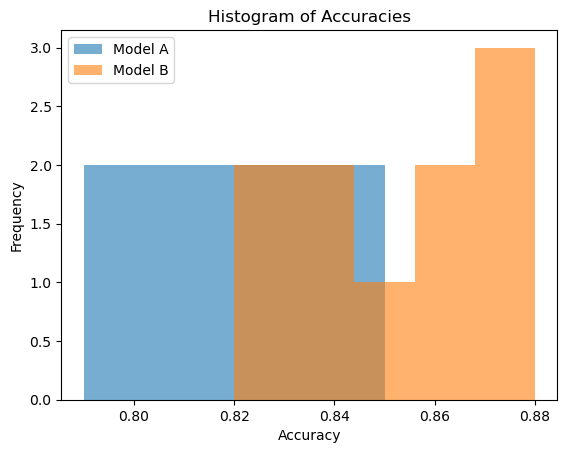

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
 
model_a = np.array([0.82, 0.80, 0.83, 0.85, 0.81, 0.79, 0.84, 0.82, 0.83, 0.81])
model_b = np.array([0.84, 0.85, 0.86, 0.87, 0.83, 0.82, 0.88, 0.86, 0.87, 0.84])


# 2. Descriptive Statistics

def descriptive_stats(data):
    return {
        "Mean": np.mean(data),
        "Variance": np.var(data, ddof=1),
        "Std Dev": np.std(data, ddof=1),
        "Skewness": stats.skew(data),
        "Kurtosis": stats.kurtosis(data)
    }

desc_a = descriptive_stats(model_a)
desc_b = descriptive_stats(model_b)


# 3. Confidence Intervals (95%)

def confidence_interval(data, confidence=0.95):
    mean = np.mean(data)
    sem = stats.sem(data)  # standard error
    margin = sem * stats.t.ppf((1 + confidence) / 2, len(data) - 1)
    return (mean - margin, mean + margin)

ci_a = confidence_interval(model_a)
ci_b = confidence_interval(model_b)


# 4. PIndependent t-test

t_stat, p_value = stats.ttest_ind(model_a, model_b, equal_var = False)
decision = "Reject H0 (significant difference)" if p_value < 0.05 else "Fail to reject H0"


# 5. Print Results

print("=== Descriptive Statistics ===")
print("Model A:", desc_a)
print("Model B:", desc_b)

print("\n=== 95% Confidence Intervals ===")
print(f"Model A: {ci_a}")
print(f"Model B: {ci_b}")

print("\n=== Paired t-test ===")
print(f"t-statistic = {t_stat:.4f}, p-value = {p_value:.6f}")
print("Decision:", decision)


# 6. Visualization

# Boxplot
plt.boxplot([model_a, model_b], labels=["Model A", "Model B"])
plt.title("Box Plot of Accuracies")
plt.ylabel("Accuracy")
plt.show()

# Histogram
plt.hist(model_a, alpha=0.6, bins=5, label="Model A")
plt.hist(model_b, alpha=0.6, bins=5, label="Model B")
plt.title("Histogram of Accuracies")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [3]:
import numpy as np
import pandas as pd


rng = np.random.default_rng(seed=42)

group1 = rng.normal(loc=50, scale=5, size=10)  # mean around 50
group2 = rng.normal(loc=55, scale=5, size=10)  # mean around 55
group3 = rng.normal(loc=60, scale=5, size=10)  # mean around 60


df = pd.DataFrame({
    "Group1": group1,
    "Group2": group2,
    "Group3": group3,
})


from scipy.stats import f_oneway

stat, p_value = f_oneway(group1, group2, group3)
alpha = 0.05

if p_value < alpha:
    print("Reject null hypothesis")
else:
    print("Failed to reject null hypothesis")

Reject null hypothesis
